<a href="https://colab.research.google.com/github/crahulnaidu/quantum_computing/blob/main/month_2/month_2_day_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
!pip install qiskit
!pip install qiskit_aer
!pip install qiskit_algorithms


In [17]:
!pip install Estimator

  Preparing metadata (setup.py) ... done
  Created wheel for Estimator: filename=estimator-0.0.10-py3-none-any.whl size=7616 sha256=e5c799ec75843ab419294a4e6a06595da7f71aa4f50d95e6ddd2f8cbe852d9a5
  Stored in directory: /root/.cache/pip/wheels/d3/97/a9/7d5832825729d80c6f5da3a208b16f32b7ff6d9192500d88ce
Successfully built Estimator


In [2]:
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.quantum_info import Statevector,SparsePauliOp
import numpy as np

In [3]:
theta=Parameter("0")

qc=QuantumCircuit(1)
qc.ry(theta,0)

In [8]:
H=SparsePauliOp.from_list([("Z",1)])

for val in np.linspace(0,2*np.pi,20):
  bound=qc.assign_parameters({theta:val})
  state=Statevector.from_instruction(bound)
  energy=np.real(state.expectation_value(H))
  print(val,energy)


0.0 1.0
0.3306939635357677 0.9458172417006346
0.6613879270715354 0.7891405093963936
0.992081890607303 0.5469481581224269
1.3227758541430708 0.24548548714079904
1.6534698176788385 -0.08257934547233226
1.984163781214606 -0.40169542465296926
2.3148577447503738 -0.677281571625741
2.6455517082861415 -0.879473751206489
2.9762456718219092 -0.9863613034027223
3.306939635357677 -0.9863613034027223
3.6376335988934447 -0.8794737512064891
3.968327562429212 -0.6772815716257414
4.29902152596498 -0.4016954246529698
4.6297154895007475 -0.08257934547233292
4.960409453036515 0.24548548714079882
5.291103416572283 0.5469481581224266
5.621797380108051 0.7891405093963935
5.9524913436438185 0.9458172417006345
6.283185307179586 1.0


In [9]:
#A 2 qubit ansatz.

In [29]:
from qiskit_algorithms.optimizers import COBYLA
from qiskit.primitives import StatevectorEstimator as Estimator
import matplotlib.pyplot as plt

In [27]:
theta1=Parameter("01")
theta2=Parameter("02")

ansatz=QuantumCircuit(2)
ansatz.ry(theta1,0)
ansatz.ry(theta2,1)
ansatz.cx(0,1)

ansatz.draw()

┌────────┐     
q_0: ┤ Ry(01) ├──■──
     ├────────┤┌─┴─┐
q_1: ┤ Ry(02) ├┤ X ├
     └────────┘└───┘

<>:15: SyntaxWarning: invalid escape sequence '\l'
<>:15: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_58942/910634817.py:15: SyntaxWarning: invalid escape sequence '\l'
  plt.plot(points,energies,label="Expectation Value $\langle ZI + IZ \\rangle $")


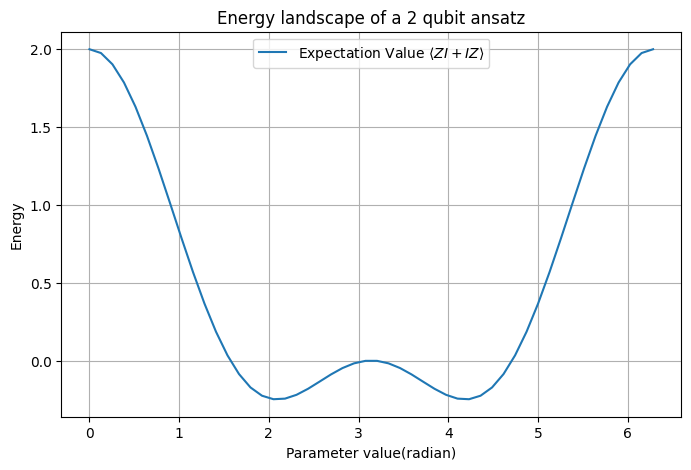

In [33]:
hamiltonian=SparsePauliOp.from_list([("ZI",1.0),("IZ",1.0)])

estimator=Estimator()
points=np.linspace(0,2*np.pi,50)
energies=[]

for val in points:
  pub=(ansatz,hamiltonian,[val,val])
  job=estimator.run([pub])
  result=job.result()
  energies.append(result[0].data.evs)


plt.figure(figsize=(8,5))
plt.plot(points,energies,label="Expectation Value $\langle ZI + IZ \\rangle $")
plt.xlabel("Parameter value(radian)")
plt.ylabel("Energy")
plt.title("Energy landscape of a 2 qubit ansatz")
plt.grid(True)
plt.legend()
plt.show()


In [36]:
def cost_func(params):
  pub=(ansatz,hamiltonian,params)
  job=estimator.run([pub])
  result=job.result()
  return float(result[0].data.evs)

In [37]:
initial_guess=[0.1,0.1]
optimizer=COBYLA(maxiter=100)
result=optimizer.minimize(fun=cost_func,x0=initial_guess)


print(f"Minimum energy found:{result.fun:.4f}")
print(f"Optimal parameters : 01={result.x[0]:.4f},02={result.x[1]:.4f}")

Minimum energy found:-2.0000
Optimal parameters : 01=3.1416,02=-0.0001
